In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split



In [2]:
df = pd.read_csv(
    "../data/cleaned/hotel_bookings_cleaned.csv",
    index_col=0
)
df.shape

(87395, 35)

In [3]:
# create target variable

y = df["is_canceled"]

In [4]:
# remove data leakage columns

columns_to_drop = [
    "is_canceled",
    "reservation_status",
    "reservation_status_date"
]

X = df.drop(columns=columns_to_drop)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (87395, 32)
y Shape: (87395,)


In [5]:
# identify catagorical columns

categorical_cols = X.select_dtypes(include=["object", "string"]).columns

print(categorical_cols)
print("Number of categorical columns:", len(categorical_cols))

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type'],
      dtype='str')
Number of categorical columns: 10


In [6]:
# identify numerical columns

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print(numerical_cols)
print("Number of numerical columns:", len(numerical_cols))

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'total_stay', 'total_guests', 'is_family'],
      dtype='str')
Number of numerical columns: 22


In [7]:
# check the target distribution

print(y.value_counts())
print("\nPercentage Distribution:")
print((y.value_counts(normalize=True) * 100).round(2))

is_canceled
0    63371
1    24024
Name: count, dtype: int64

Percentage Distribution:
is_canceled
0    72.51
1    27.49
Name: proportion, dtype: float64


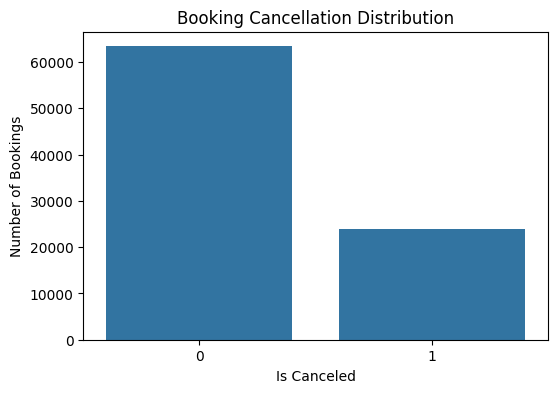

In [8]:
# visualize

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Is Canceled")
plt.ylabel("Number of Bookings")

plt.savefig(
    "../screenshots/week3/target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
print(X.isnull().sum().sum())

0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [11]:
# One-Hot Encode Categorical Columns

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [12]:
# Check the Encoded Dataset

print("Encoded Dataset Shape:", X_encoded.shape)

X_encoded.head()

Encoded Dataset Shape: (87395, 251)


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,...,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L,assigned_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,342,2015,27,1,0,0,2,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,737,2015,27,1,0,0,2,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,7,2015,27,1,0,1,1,0,0,0,...,False,False,False,False,False,False,False,False,True,False
3,13,2015,27,1,0,1,1,0,0,0,...,False,False,False,False,False,False,False,False,True,False
4,14,2015,27,1,0,2,2,0,0,0,...,False,False,False,False,False,False,False,False,True,False


In [13]:
# Confirm All Features Are Numeric

X_encoded.info()

print(X_encoded.select_dtypes(include=["object", "string"]).columns)    

<class 'pandas.DataFrame'>
Index: 87395 entries, 0 to 119389
Columns: 251 entries, lead_time to customer_type_Transient-Party
dtypes: bool(229), float64(3), int64(19)
memory usage: 34.4 MB
Index([], dtype='str')


In [14]:
# convert the booleans to integers

bool_cols = X_encoded.select_dtypes(include="bool").columns

X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

X_encoded.info()

<class 'pandas.DataFrame'>
Index: 87395 entries, 0 to 119389
Columns: 251 entries, lead_time to customer_type_Transient-Party
dtypes: float64(3), int64(248)
memory usage: 168.0 MB


In [15]:
# train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# verify shapes

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# verify class distribution

print("Training Distribution")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Distribution")
print((y_test.value_counts(normalize=True) * 100).round(2))

X_train: (69916, 251)
X_test : (17479, 251)
y_train: (69916,)
y_test : (17479,)
Training Distribution
is_canceled
0    72.51
1    27.49
Name: proportion, dtype: float64

Testing Distribution
is_canceled
0    72.51
1    27.49
Name: proportion, dtype: float64


In [16]:
# train machine learning models

# import required libraries

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [17]:
# train logistic regression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)

# prediction

log_pred = log_model.predict(X_test)

# evaluate logistic regression

print("Logistic Regression")

print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall   :", recall_score(y_test, log_pred))
print("F1 Score :", f1_score(y_test, log_pred))

Logistic Regression
Accuracy : 0.7825390468562274
Precision: 0.665785997357992
Recall   : 0.41956295525494275
F1 Score : 0.514745308310992


c:\Users\Dipanjan Ghosh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
# train decision tree

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

# predictions

dt_pred = dt_model.predict(X_test)

# evaluate decision tree

print("Decision Tree")

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Decision Tree
Accuracy : 0.7994736540992048
Precision: 0.6338550247116969
Recall   : 0.640582726326743
F1 Score : 0.6372011178966981


In [19]:
# train random forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# predictions

rf_pred = rf_model.predict(X_test)

# evaluate random forest

print("Random Forest")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Random Forest
Accuracy : 0.8478173808570284
Precision: 0.7780658542908997
Recall   : 0.6245577523413112
F1 Score : 0.6929115677672593


In [20]:
# compare models

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
}

results_df = pd.DataFrame(results)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7825,0.6658,0.4196,0.5147
1,Decision Tree,0.7995,0.6339,0.6406,0.6372
2,Random Forest,0.8478,0.7781,0.6246,0.6929


# Random Forest was selected as the final model because it provided the best balance between prediction accuracy and reliability for identifying booking cancellations.

In [21]:
results_df.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

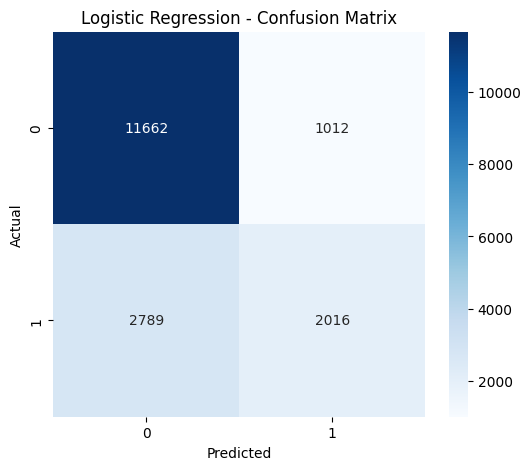

In [22]:
# Model evaluation

# import libraries

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# confusion matrix-logistic regression 

cm_log = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../screenshots/week3/logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

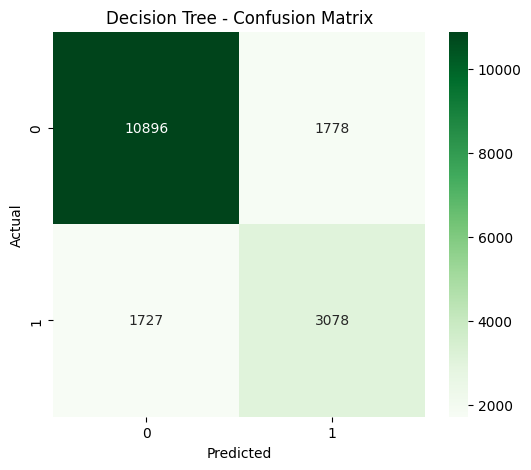

In [23]:
# decision tree confusion matrix

cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../screenshots/week3/decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

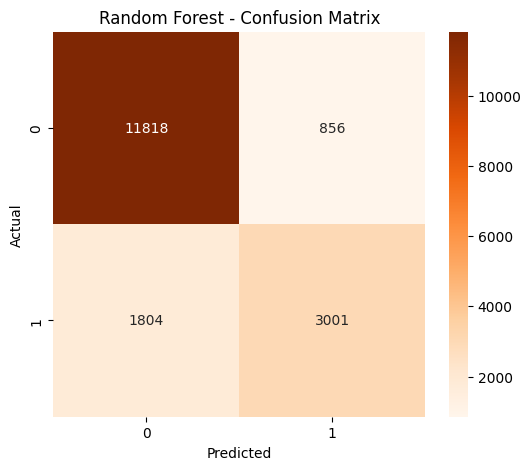

In [24]:
# random forest confusion matrix

cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../screenshots/week3/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# classification reports

print("========== Logistic Regression ==========")
print(classification_report(y_test, log_pred))

print("========== Decision Tree ==========")
print(classification_report(y_test, dt_pred))

print("========== Random Forest ==========")
print(classification_report(y_test, rf_pred))

========== Logistic Regression ==========
              precision    recall  f1-score   support

           0       0.81      0.92      0.86     12674
           1       0.67      0.42      0.51      4805

    accuracy                           0.78     17479
   macro avg       0.74      0.67      0.69     17479
weighted avg       0.77      0.78      0.76     17479

========== Decision Tree ==========
              precision    recall  f1-score   support

           0       0.86      0.86      0.86     12674
           1       0.63      0.64      0.64      4805

    accuracy                           0.80     17479
   macro avg       0.75      0.75      0.75     17479
weighted avg       0.80      0.80      0.80     17479

========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     12674
           1       0.78      0.62      0.69      4805

    accuracy                           0.85     17479
   macro avg  

In [26]:
# ROC-AUC scores

log_prob = log_model.predict_proba(X_test)[:,1]
dt_prob = dt_model.predict_proba(X_test)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:,1]

print("Logistic Regression AUC :", roc_auc_score(y_test, log_prob))

print("Decision Tree AUC :", roc_auc_score(y_test, dt_prob))

print("Random Forest AUC :", roc_auc_score(y_test, rf_prob))

Logistic Regression AUC : 0.8184681676433453
Decision Tree AUC : 0.7519842173633962
Random Forest AUC : 0.9051718619993869


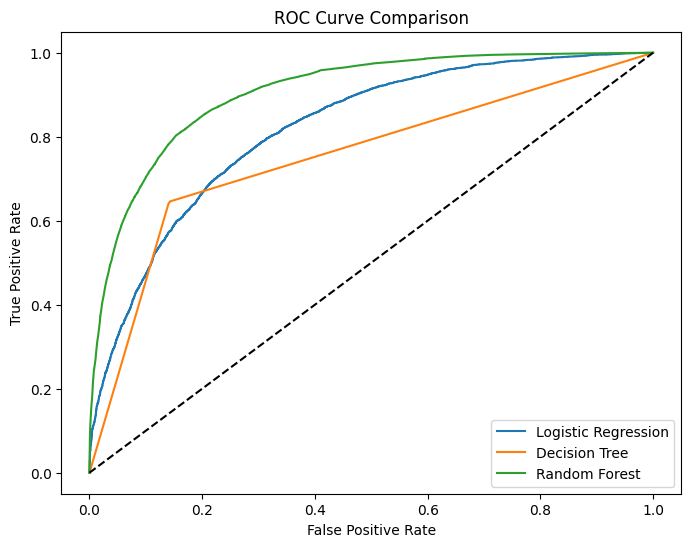

In [27]:
# plot ROC curves

fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig(
    "../screenshots/week3/roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

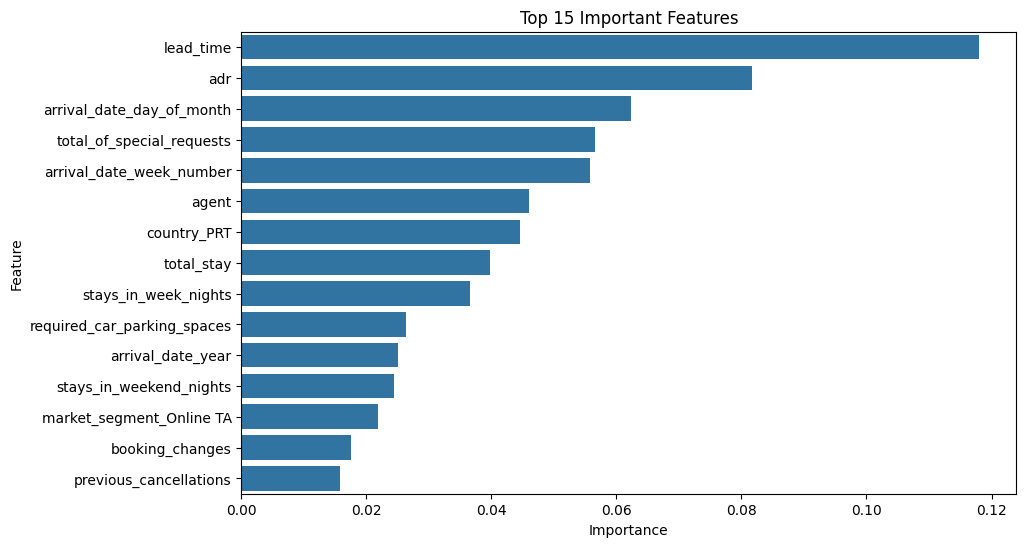

In [28]:
# feature importance

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

# plot feature importance0

top15 = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top15,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.savefig(
    "../screenshots/week3/top15_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
# save reports

feature_importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

In [30]:
import joblib

# save the random forest model

joblib.dump(
    rf_model,
    "../models/random_forest_model.pkl"
)

# save feature column names

joblib.dump(
    X_encoded.columns.tolist(),
    "../models/feature_columns.pkl"
)



['../models/feature_columns.pkl']

In [31]:
# verify saved files

import os

print(os.listdir("../models"))

['feature_columns.pkl', 'random_forest_model.pkl']


In [32]:
# load the saved model

loaded_model = joblib.load(
    "../models/random_forest_model.pkl"
)

feature_columns = joblib.load(
    "../models/feature_columns.pkl"
)

In [33]:
# test the saved model

loaded_model.predict(X_test.iloc[:5])

array([0, 0, 0, 0, 0])

In [34]:
y_test.iloc[:5]

20976    0
33649    0
39233    0
9323     1
36610    0
Name: is_canceled, dtype: int64

In [35]:
df.to_csv(
    "../data/cleaned/hotel_bookings_cleaned.csv"
)

In [36]:
test = pd.read_csv(
    "../data/cleaned/hotel_bookings_cleaned.csv",
    index_col=0
)

test.shape

(87395, 35)